---
title: "Practice Activity 8.2: Classification"
author: Lily
format:
    html:
        embed-resources: true
        code-line-numbers: true
---

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%207>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `species` using the other variables in the dataset.

**Dummify** all variables that require this.

In [1]:
### packages
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

# bonus
import matplotlib.pyplot as plt

In [2]:
### Penguin data
!pip install palmerpenguins
from palmerpenguins import load_penguins

In [3]:
### set up penguins df
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
### Making dummies
penguins = pd.get_dummies(penguins)
# this math converts bools to numbers
penguins = penguins * 1
# visual confirmation of data
penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,39.1,18.7,181.0,3750.0,2007,1,0,0,0,0,1,0,1
1,39.5,17.4,186.0,3800.0,2007,1,0,0,0,0,1,1,0
2,40.3,18.0,195.0,3250.0,2007,1,0,0,0,0,1,1,0
3,NaN,NaN,NaN,NaN,2007,1,0,0,0,0,1,0,0
4,36.7,19.3,193.0,3450.0,2007,1,0,0,0,0,1,1,0


In [5]:
### Drop other NAs
penguins = penguins.dropna()

In [6]:
### specify x variables and y variable
#X = penguins[["bill_depth_mm"]]
X = penguins.drop(["species_Gentoo", "species_Chinstrap", "species_Adelie"], axis = 1)
y = penguins["species_Gentoo"]

Let's use the other variables to predict `species`. Prepare your data and fit the following models on the entire dataset:

* Two kNN models (for different values of K)
* Two decision tree models (for different complexities of trees)

Compute the following, for each of your models, on test data. Keep in mind that you may need to stratify your creation of the training and test data.

* Confusion matrix
* Overall Accuracy
* Precision, Recall, AUC, and F1-score for each species

Create one ROC plot for the species of your choice.

In [7]:
### KNN

# start by tuning to see best number of neighbors
knn_pipeline = Pipeline(
    [
     ("standardize", StandardScaler()),
     ("knn", KNeighborsClassifier())
    ],
).set_output(transform="pandas")

neighbors = {'knn__n_neighbors': np.arange(1, 11, 1)}

# addressing stratification
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

gscv = GridSearchCV(knn_pipeline, param_grid=neighbors, cv = cv, scoring='f1')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011907,0.003764,0.013915,0.002553,1,{'knn__n_neighbors': 1},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
1,0.010410,0.002499,0.011950,0.000904,2,{'knn__n_neighbors': 2},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
2,0.009931,0.000991,0.011727,0.000640,3,{'knn__n_neighbors': 3},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
3,0.009135,0.000380,0.011818,0.000369,4,{'knn__n_neighbors': 4},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
4,0.008952,0.000384,0.011233,0.000487,5,{'knn__n_neighbors': 5},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
5,0.009598,0.000816,0.012370,0.001448,6,{'knn__n_neighbors': 6},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
6,0.009530,0.000445,0.011315,0.000389,7,{'knn__n_neighbors': 7},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
7,0.009130,0.000569,0.011761,0.000589,8,{'knn__n_neighbors': 8},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
8,0.008922,0.001534,0.010362,0.001814,9,{'knn__n_neighbors': 9},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
9,0.009170,0.001961,0.013887,0.001881,10,{'knn__n_neighbors': 10},1.0,1.0,1.0,1.0,1.0,1.0,0.0,1


I found it really suspicious that I got all 1.0s for every mean test score. I tried out different scoring types, a wider range of possible neighbors, and removing which X variables I included. When I only use bill_depth_mm, I get more realistic numbers (and not all the same).

This leads me to believe that the code I wrote is ok, but somehow the model is just that good when classifying and using most / all of the variables. There may be certain variables that make it very clear that a penguin is the Gentoo species, so it will match all of its neighbors.

In [8]:
# make pipeline for neighbors = 10
knn_first_pipeline = Pipeline(
  [("standardize", StandardScaler()),
   ("knn", KNeighborsClassifier(n_neighbors = 10))
  ]
).set_output(transform="pandas")

# fit
knn_first_pipeline_fitted = knn_first_pipeline.fit(X, y)

In [9]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(knn_first_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[219   0]
 [  0 123]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      1.00      1.00       123

    accuracy                           1.00       342
   macro avg       1.00      1.00      1.00       342
weighted avg       1.00      1.00      1.00       342



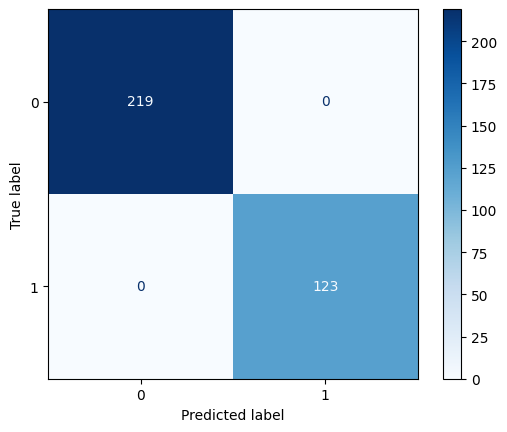

In [10]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(knn_first_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

In [11]:
# make pipeline for neighbors = 1
knn_second_pipeline = Pipeline(
  [("standardize", StandardScaler()),
   ("knn", KNeighborsClassifier(n_neighbors = 1))
  ]
).set_output(transform="pandas")

# fit
knn_second_pipeline_fitted = knn_first_pipeline.fit(X, y)

In [12]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(knn_second_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[219   0]
 [  0 123]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      1.00      1.00       123

    accuracy                           1.00       342
   macro avg       1.00      1.00      1.00       342
weighted avg       1.00      1.00      1.00       342



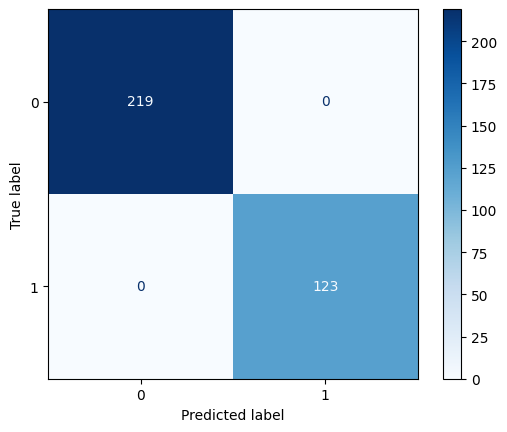

In [13]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(knn_second_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

In [14]:
### Decision Tree

# start by tuning to see best number of neighbors
dt_pipeline = Pipeline(
    [
     ("dt", DecisionTreeClassifier())
    ],
).set_output(transform="pandas")

tuning = {'dt__ccp_alpha': np.arange(0, 1, 0.1)}

# addressing stratification
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

gscv = GridSearchCV(dt_pipeline, param_grid=tuning, cv = cv, scoring='f1')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dt__ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007430,0.002757,0.010479,0.003825,0.0,{'dt__ccp_alpha': 0.0},1.000000,0.979592,1.000000,1.000000,1.000000,0.995918,0.008163,1
1,0.011059,0.006626,0.014692,0.005955,0.1,{'dt__ccp_alpha': 0.1},0.961538,0.979592,0.978723,0.979592,0.943396,0.968568,0.014347,2
2,0.007128,0.002880,0.009988,0.002646,0.2,{'dt__ccp_alpha': 0.2},0.961538,0.979592,0.978723,0.979592,0.943396,0.968568,0.014347,2
3,0.006365,0.000810,0.008592,0.002097,0.3,{'dt__ccp_alpha': 0.30000000000000004},0.961538,0.979592,0.978723,0.979592,0.943396,0.968568,0.014347,2
4,0.015155,0.005752,0.022461,0.008403,0.4,{'dt__ccp_alpha': 0.4},0.961538,0.979592,0.978723,0.979592,0.943396,0.968568,0.014347,2
5,0.009691,0.003919,0.015281,0.006989,0.5,{'dt__ccp_alpha': 0.5},0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
6,0.005699,0.000436,0.009235,0.004218,0.6,{'dt__ccp_alpha': 0.6000000000000001},0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
7,0.005381,0.000134,0.006684,0.000207,0.7,{'dt__ccp_alpha': 0.7000000000000001},0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
8,0.005233,0.000079,0.007313,0.000857,0.8,{'dt__ccp_alpha': 0.8},0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6
9,0.008727,0.002774,0.012523,0.004372,0.9,{'dt__ccp_alpha': 0.9},0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6


In [15]:
# make pipeline for max depth = 10
dt_first_pipeline = Pipeline(
  [("dt", DecisionTreeClassifier(ccp_alpha=0, max_depth=10))]
).set_output(transform="pandas")

# fit
dt_first_pipeline_fitted = dt_first_pipeline.fit(X, y)

In [16]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(dt_first_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[218   1]
 [  1 122]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       0.99      0.99      0.99       123

    accuracy                           0.99       342
   macro avg       0.99      0.99      0.99       342
weighted avg       0.99      0.99      0.99       342



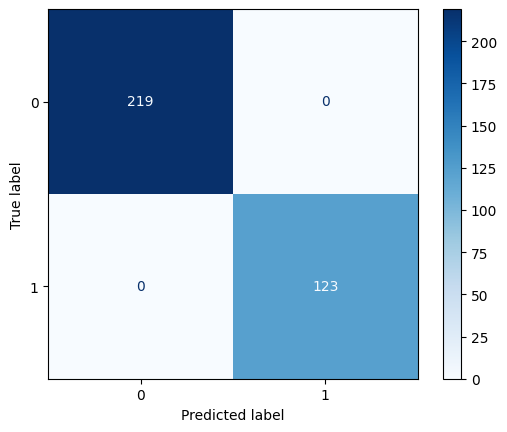

In [17]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(dt_first_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

In [18]:
# make pipeline for max depth = 1
dt_second_pipeline = Pipeline(
  [("decision_tree", DecisionTreeClassifier(ccp_alpha=0, max_depth=1))]
).set_output(transform="pandas")

# fit
dt_second_pipeline_fitted = dt_second_pipeline.fit(X, y)

In [19]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(dt_second_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[213   6]
 [  2 121]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       219
           1       0.95      0.98      0.97       123

    accuracy                           0.98       342
   macro avg       0.97      0.98      0.97       342
weighted avg       0.98      0.98      0.98       342



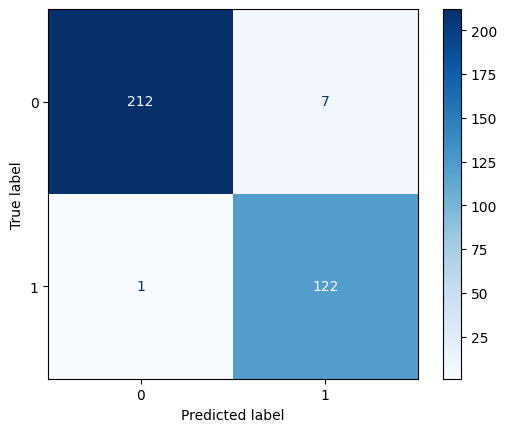

In [20]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(dt_second_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

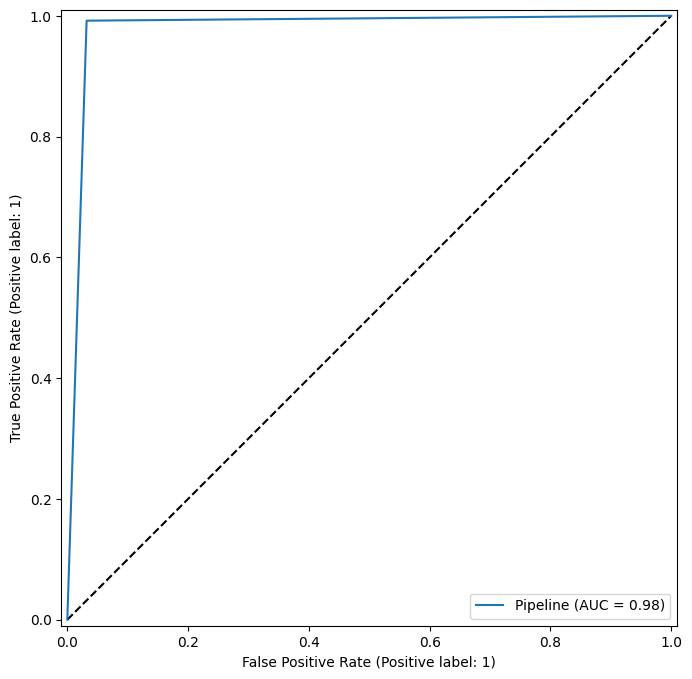

In [21]:
### ROC curve for second decision tree (max_depth = 1)

fig, ax = plt.subplots(figsize = (8, 8))

ax.plot(ax.get_xlim(), ax.get_ylim(), ls = '--', c = 'k')
RocCurveDisplay.from_estimator(dt_second_pipeline_fitted,
                               X = X,
                               y = y,
                               ax = ax);

In [22]:
y_score = dt_second_pipeline_fitted.predict_proba(X)[:, 1]
roc_auc_score(y, y_score)

np.float64(0.9799532241897759)